In [1]:
import xarray as xr
import numpy as np
import pandas as pd
from pathlib import Path

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')


In [3]:
outdir = 'df_filtered_mcs_track_ids/'

In [4]:
df_trop_obs= pd.read_pickle(outdir+'df_trop_obs.pkl')
df_trop_obsv7= pd.read_pickle(outdir+'df_trop_obs_v7.pkl')
df_trop_icon= pd.read_pickle(outdir+'df_trop_icon.pkl')
df_trop_scream= pd.read_pickle(outdir+'df_trop_scream.pkl')
df_trop_um= pd.read_pickle(outdir+'df_trop_um.pkl')
df_trop_ifs= pd.read_pickle(outdir+'df_trop_ifs.pkl')
df_trop_nicam= pd.read_pickle(outdir+'df_trop_nicam.pkl')

In [5]:
df_trop_obs2= pd.read_pickle(outdir+'df_trop_obs_min2.pkl')
df_trop_obs2v7= pd.read_pickle(outdir+'df_trop_obs_v7_min2.pkl')
df_trop_icon2= pd.read_pickle(outdir+'df_trop_icon_min2.pkl')
df_trop_scream2= pd.read_pickle(outdir+'df_trop_scream_min2.pkl')
df_trop_um2= pd.read_pickle(outdir+'df_trop_um_min2.pkl') 
df_trop_ifs2= pd.read_pickle(outdir+'df_trop_ifs_min2.pkl')
df_trop_nicam2= pd.read_pickle(outdir+'df_trop_nicam_min2.pkl')

In [7]:
# df_trop_obs_nm= pd.read_pickle(outdir+'df_trop_obs_nm.pkl')
# df_trop_icon_nm= pd.read_pickle(outdir+'df_trop_icon_nm.pkl')
# df_trop_scream_nm= pd.read_pickle(outdir+'df_trop_scream_nm.pkl')
# df_trop_um_nm= pd.read_pickle(outdir+'df_trop_um_nm.pkl')
# df_trop_ifs_nm= pd.read_pickle(outdir+'df_trop_ifs_nm.pkl')
# df_trop_nicam_nm= pd.read_pickle(outdir+'df_trop_nicam_nm.pkl')

# df_trop_obs_np= pd.read_pickle(outdir+'df_trop_obs_min_np.pkl')
# df_trop_icon_np= pd.read_pickle(outdir+'df_trop_icon_min_np.pkl')
# df_trop_scream_np= pd.read_pickle(outdir+'df_trop_scream_min_np.pkl')
# df_trop_um_np= pd.read_pickle(outdir+'df_trop_um_min_np.pkl') 
# df_trop_ifs_np= pd.read_pickle(outdir+'df_trop_ifs_np.pkl')
# df_trop_nicam_np= pd.read_pickle(outdir+'df_trop_nicam_np.pkl')

In [6]:
## load circular land fractions
ldir = '/pscratch/sd/p/paccini/temp/hackathon/updated_land_fractions/'
lf_scream = pd.read_parquet(ldir+'mcs_land_fractions_scream_ne120_zoom8_summary.parquet')
lf_um = pd.read_parquet(ldir+'mcs_land_fractions_um_glm_n2560_RAL3p3_zoom8_summary.parquet')
lf_icon = pd.read_parquet(ldir+'mcs_land_fractions_icon_d3hp003_zoom8_summary.parquet')
lf_nicam = pd.read_parquet(ldir+'for_nicam/mcs_land_fractions_scream_ne120_zoom8_summary.parquet')
lf_ifs = pd.read_parquet(ldir+'for_ifs/mcs_land_fractions_scream_ne120_zoom8_summary.parquet')
lf_obs = pd.read_parquet(ldir+'for_era5/mcs_land_fractions_scream_ne120_zoom8_summary.parquet')
lf_obsv7 = pd.read_parquet(ldir+'for_era5_imergv7/mcs_land_fractions_scream_ne120_zoom8_summary.parquet')

In [7]:
# --- 1. Setup Configuration ---
colors = {
    'IMERGv7': 'k', 'IMERGv6': 'gray', 'ICON': '#ff7f0e', 
    'SCREAM': '#2ca02c', 'UM': 'salmon', 'IFS': "steelblue", 
    "NICAM": "mediumpurple"
}

# Define metadata for each model to iterate easily
# Format: (Label, Main_DF, LandFrac_DF, LineWidth)
# Assumption: df_trop_* and lf_* variables are already loaded in your environment
model_configs = [
    ('ICON',    df_trop_icon,   lf_icon,   1.5),
    ('SCREAM',  df_trop_scream, lf_scream, 1.5),
    ('UM',      df_trop_um,     lf_um,     1.5),
    ('IFS',     df_trop_ifs,    lf_ifs,    1.5),
    ('NICAM',   df_trop_nicam,  lf_nicam,  1.5),
    ('IMERGv6', df_trop_obs,    lf_obs,    2.8),
    ('IMERGv7', df_trop_obsv7,  lf_obsv7,  2.8),
]

# --- 2. Optimized Processing Function ---
def process_and_filter(df_main, df_lf, radius=2, lf_thresh=0.1,lf_var='total_land_fraction_track'):
    """
    Merges main data with land fraction data and filters by radius and threshold.
    """
    # 1. Filter Land Fraction by radius
    lf_subset = df_lf[df_lf['radius'] == radius].copy()
    
    # 2. Safe Merge (Inner Join) on track_id to ensure data integrity
    # Adjust 'track_id' if your column names differ between dataframes
    merged_df = pd.merge(
        df_main, 
        lf_subset[['track_id', lf_var]], 
        on='track_id', 
        how='inner'
    )
    
    # 3. Filter by Land Fraction Threshold
    # Ensure it handles NaNs if necessary, though inner join usually drops non-matches
    final_df = merged_df[merged_df[lf_var] <= lf_thresh].copy()
    
    return final_df



In [8]:
def remove_longdurations(df_model, feature='duration_hours', p_high=0.9):
    if df_model is None:
        return None
    q_high = df_model[feature].quantile(p_high)
    df_filtered = df_model[(df_model[feature] <= q_high)].copy()
    return df_filtered.reset_index(drop=True)

In [9]:
# --- 3. Process all models at once ---
# Store processed data in a dictionary for easy access
processed_data = {}

for label, df_m, df_l, lw in model_configs:
    # Process
    cleandf = process_and_filter(df_m, df_l)
    clean_df = remove_longdurations(cleandf)
    # Calculate derived columns immediately to save time during plotting
    # 1. Duration (already exists)
    # 2. Equivalent Diameter
    valid_area_mask = clean_df['lifetime_maxmax_pf_area'] > 0
    clean_df.loc[valid_area_mask, 'calc_diameter'] = 2 * np.sqrt(clean_df.loc[valid_area_mask, 'lifetime_maxmax_pf_area'])
    
    # Store in dict
    processed_data[label] = {
        'df': clean_df,
        'lw': lw,
        'color': colors[label]
    }

In [95]:
model_configs_v2 = [
    ('ICON',    df_trop_icon2,   lf_icon,   1.5),
    ('SCREAM',  df_trop_scream2, lf_scream, 1.5),
    ('UM',      df_trop_um2,     lf_um,     1.5),
    ('IFS',     df_trop_ifs2,    lf_ifs,    1.5),
    ('NICAM',   df_trop_nicam2,  lf_nicam,  1.5),
    ('IMERGv6', df_trop_obs2,    lf_obs,    2.8),
    ('IMERGv7', df_trop_obs2v7,  lf_obsv7,  2.8),
]

processed_data_v2 = {}

for label, df_m, df_l, lw in model_configs_v2:
    # Process
    cleandf_v2 = process_and_filter(df_m, df_l)
    clean_df_v2 = remove_longdurations(cleandf_v2)
    # Calculate derived columns immediately to save time during plotting
    # 1. Duration (already exists)
    # 2. Equivalent Diameter
    valid_area_mask = clean_df_v2['lifetime_maxmax_pf_area'] > 0
    clean_df_v2.loc[valid_area_mask, 'calc_diameter'] = 2 * np.sqrt(clean_df_v2.loc[valid_area_mask, 'lifetime_maxmax_pf_area'])

    valid_area_mask2 = clean_df_v2['total_total_rain'] > 0
    clean_df_v2.loc[valid_area_mask2, 'total_rain_area_diameter'] = 2 * np.sqrt(clean_df_v2.loc[valid_area_mask2, 'total_total_rain'])

    valid_area_mask3 = clean_df_v2['total_area'] > 0
    clean_df_v2.loc[valid_area_mask2, 'total_area_diameter'] = 2 * np.sqrt(clean_df_v2.loc[valid_area_mask3, 'total_area'])
    
    # Store in dict
    processed_data_v2[label] = {
        'df': clean_df_v2,
        'lw': lw,
        'color': colors[label]
    }

In [25]:
# --- 4. Plotting Configuration ---

# Define settings for the 4 subplots
# transformation: function to apply to data (optional)
plot_settings = [
    {
        'id': 'a)', 
        'col': 'duration_hours', 
        'bins': np.arange(0, 60, 3), 
        'xlabel': 'Duration (hours)', 
        'log_scale': False,
        'xlim': (2, 55),
        'transform': None 
    },
    {
        'id': 'b)', 
        'col': 'calc_diameter', # Calculated in previous step
        'bins': np.arange(0, 800, 30), 
        'xlabel': 'Lifetime Max Precipitating Eq. Diameter (km)', 
        'log_scale': False,
        'xlim': None,
        'transform': None
    },
    {
        'id': 'c)', 
        'col': 'total_total_rain', 
        'bins': np.logspace(np.log10(100), np.log10(5*1e6), num=30), 
        'xlabel': 'Lifetime total precipitation (mm)', 
        'log_scale': True, 
        'xlim': (1e3, 2*1e6),
        'ylim': (1e-1, 21),
        'transform': lambda x: x[x > 0] # Filter > 0 for log plots
    },
    {
        'id': 'd)', 
        'col': 'median_aspectratio', 
        'bins': np.arange(0.8, 4, 0.2), 
        'xlabel': 'Aspect ratio', 
        'log_scale': False,
        'xlim': (1, 3.6),
        'transform': None
    }
]


In [13]:
# --- 4. Plotting Configuration ---

# Define settings for the 4 subplots
# transformation: function to apply to data (optional)
plot_settings = [
    {
        'id': 'a)', 
        'col': 'total_total_rain', 
        'bins': np.logspace(np.log10(100), np.log10(5*1e6), num=30), 
        'xlabel': 'Lifetime total precipitation (mm)', 
        'log_scale': True, 
        'xlim': (1e3, 2*1e6),
        'ylim': (1e-1, 21),
        'transform': lambda x: x[x > 0] # Filter > 0 for log plots
    },
    {
        'id': 'b)', 
        'col': 'calc_diameter', # Calculated in previous step
        'bins': np.arange(0, 800, 30), 
        'xlabel': 'Lifetime Max Precipitating Eq. Diameter (km)', 
        'log_scale': False,
        'xlim': None,
        'transform': None
    },
    {
        'id': 'c)', 
        'col': 'duration_hours', 
        'bins': np.arange(0, 60, 3), 
        'xlabel': 'Duration (hours)', 
        'log_scale': False,
        'xlim': (2, 55),
        'transform': None 
        
    },
    {
        'id': 'd)', 
        'col': 'median_aspectratio', 
        'bins': np.arange(0.8, 4, 0.2), 
        'xlabel': 'Aspect ratio', 
        'log_scale': False,
        'xlim': (1, 3.6),
        'transform': None
    }
]


In [11]:
# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [82]:
processed_data_v2['IMERGv7']['df'][['calc_diameter',
       'total_rain_area_diameter', 'total_area_diameter']].describe()

,calc_diameter,total_rain_area_diameter,total_area_diameter
count,2650.000000,2650.000000,2650.000000
mean,413.052399,362.919373,2199.900635
std,142.489212,169.298721,827.700806
min,158.745071,109.655319,988.331909
25%,309.838654,239.724255,1594.898163
50%,387.556366,321.289047,1991.029724
75%,488.569305,445.623306,2601.576355
max,1149.260620,1185.721436,6933.945312


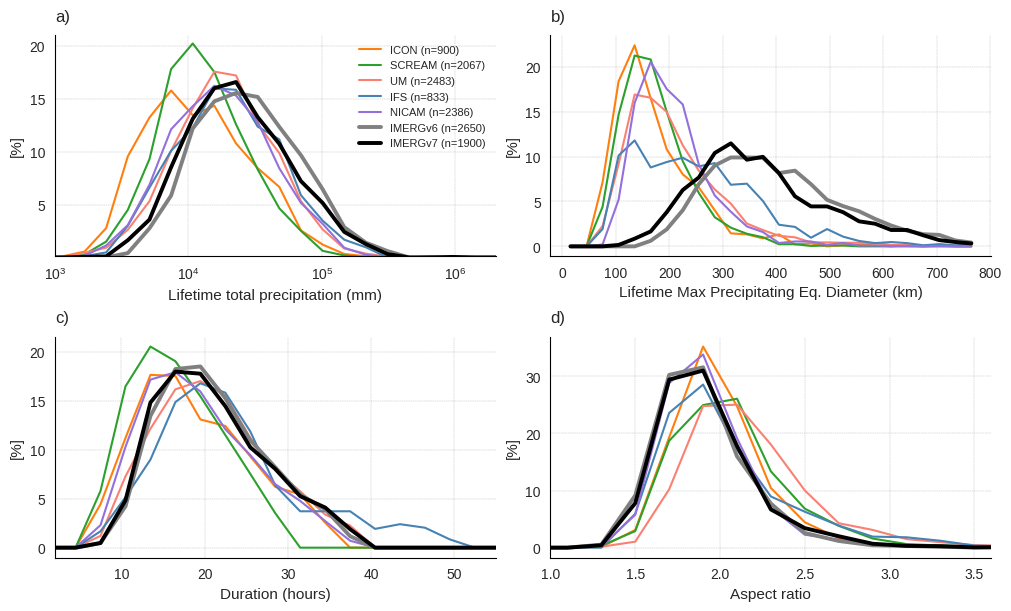

In [16]:
# --- 5. Generate Figure ---
fig, axes = plt.subplots(2, 2, figsize=(10, 6), constrained_layout=True)
axes_flat = axes.flatten() # Flatten 2x2 matrix to 1D array for easy looping

for ax, settings in zip(axes_flat, plot_settings):
    
    # Get bin centers for line plotting
    mid_bins = 0.5 * (settings['bins'][1:] + settings['bins'][:-1])
    
    # Loop through each model
    for label, props in processed_data_v2.items():
        df = props['df']
        col = settings['col']
        
        # Skip if column doesn't exist (safety check)
        if col not in df.columns: continue

        # Get Data Series
        data = df[col]
        
        # Apply specific transformations (e.g. filtering > 0 for rain)
        if settings['transform']:
            data = settings['transform'](data)
            
        # Calculate Histogram
        data_hist, _ = np.histogram(data, bins=settings['bins'], density=False)
        
        # Avoid division by zero
        total_count = data_hist.sum()
        if total_count > 0:
            perc_hist = (data_hist / total_count) * 100
        else:
            perc_hist = np.zeros_like(data_hist)

        # Plot
        ax.plot(mid_bins, perc_hist, 
                label=f'{label} (n={len(df)})', 
                color=props['color'], 
                lw=props['lw'])

    # -- Formatting the Subplot --
    ax.set_xlabel(settings['xlabel'])
    ax.set_ylabel('[%]')
    
    # Grid and Spines
    ax.set_facecolor('white')
    ax.grid(color='k', linestyle='--', linewidth=0.3, alpha=0.3)
    ax.spines['left'].set_color('k'); ax.spines['bottom'].set_color('k')
    ax.spines['left'].set_linewidth(.8); ax.spines['bottom'].set_linewidth(.8)
    
    # Specific Scales/Limits
    if settings['log_scale']:
        # ax.set_yscale('log')
        ax.set_xscale('log')
    
    if settings.get('xlim'):
        ax.set_xlim(settings['xlim'])
    
    if settings.get('ylim'):
        ax.set_ylim(settings['ylim'])

    # Title / Label placement (Left aligned letters)
    # loc='left' places it on the left, specific coordinates can fine tune it
    ax.set_title(settings['id'], loc='left', fontsize=12, pad=10)

# Add Legend only to the first plot (or where preferred) to save space
# Or put it outside: axes_flat[0].legend(...)
axes_flat[0].legend(fontsize=8, loc='best')
# plt.savefig('plots/mcs_4features_circleLF10_allconditions_2hnonmcs_longremoved_fullyear.png', dpi=300, bbox_inches='tight')

In [103]:
plot_settings = [
    {
        'id': 'a)', 
        'col': 'total_total_rain', 
        'bins': np.logspace(np.log10(100), np.log10(2*1e6), num=20), 
        'xlabel': 'mm', 
        'log_scale': True, 
        'xlim': (1e3, 3.5*1e5), #2*1e6),
        'ylim': (1e-1, None),
        'transform': lambda x: x[x > 0] # Filter > 0 for log plots
    },
    {
        'id': 'b)', 
        'col': 'calc_diameter', # Calculated in previous step
        'bins': np.arange(0, 800, 30), 
        'xlabel': 'Equivalent diameter (km)', 
        'log_scale': False,
        'xlim': None,
        'transform': None
    },
    {
        'id': 'c)', 
        'col': 'total_rain_area_diameter', 
        'bins': np.arange(0, 900, 50), 
        'xlabel': 'Equivalent diameter (km)', 
        'log_scale': False,
        'xlim':None,
        'transform': None 
        
    },
    {
        'id': 'd)', 
        'col': 'total_area_diameter', 
        'bins': np.arange(500, 5500, 250), 
        'xlabel': 'Equivalent diameter (km)', 
        'log_scale': False,
        'xlim': None,
        'transform': None
    }
]


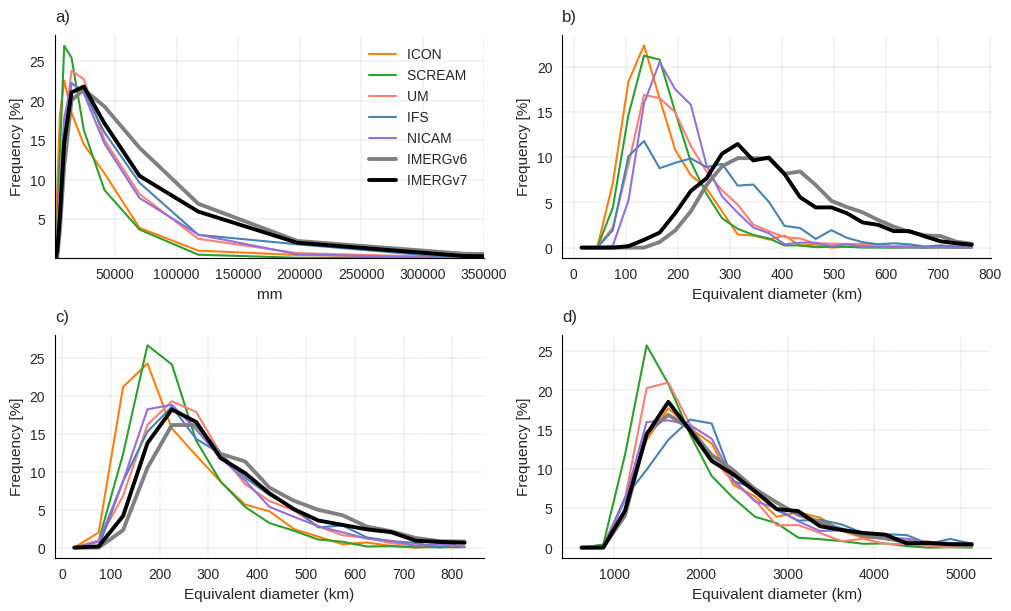

In [104]:
# --- 5. Generate Figure ---
fig, axes = plt.subplots(2, 2, figsize=(10, 6), constrained_layout=True)
axes_flat = axes.flatten() # Flatten 2x2 matrix to 1D array for easy looping

for ax, settings in zip(axes_flat, plot_settings):
    
    # Get bin centers for line plotting
    mid_bins = 0.5 * (settings['bins'][1:] + settings['bins'][:-1])
    
    # Loop through each model
    for label, props in processed_data_v2.items():
        df = props['df']
        col = settings['col']
        
        # Skip if column doesn't exist (safety check)
        if col not in df.columns: continue

        # Get Data Series
        data = df[col]
        
        # Apply specific transformations (e.g. filtering > 0 for rain)
        if settings['transform']:
            data = settings['transform'](data)
            
        # Calculate Histogram
        data_hist, _ = np.histogram(data, bins=settings['bins'], density=False)
        
        # Avoid division by zero
        total_count = data_hist.sum()
        if total_count > 0:
            perc_hist = (data_hist / total_count) * 100
        else:
            perc_hist = np.zeros_like(data_hist)

        # Plot
        ax.plot(mid_bins, perc_hist, 
                label=f'{label} ', 
                color=props['color'], 
                lw=props['lw'])

    # -- Formatting the Subplot --
    ax.set_xlabel(settings['xlabel'])
    ax.set_ylabel('Frequency [%]')
    
    # Grid and Spines
    ax.set_facecolor('white')
    ax.grid(color='k', linestyle='--', linewidth=0.3, alpha=0.3)
    ax.spines['left'].set_color('k'); ax.spines['bottom'].set_color('k')
    ax.spines['left'].set_linewidth(.8); ax.spines['bottom'].set_linewidth(.8)
    
    # Specific Scales/Limits
    # if settings['log_scale']:
    # #     # ax.set_yscale('log')
    #     ax.set_xscale('log')
    
    if settings.get('xlim'):
        ax.set_xlim(settings['xlim'])
    
    if settings.get('ylim'):
        ax.set_ylim(settings['ylim'])

    # Title / Label placement (Left aligned letters)
    # loc='left' places it on the left, specific coordinates can fine tune it
    ax.set_title(settings['id'], loc='left', fontsize=12, pad=10)

# Add Legend only to the first plot (or where preferred) to save space
# Or put it outside: axes_flat[0].legend(...)
axes_flat[0].legend(fontsize=10, loc='best')

plt.savefig('plots/mcs_4features_4AGU_fullyear_v2.png', dpi=300, bbox_inches='tight')

In [10]:
def get_filtered_df(df_model,df_tracks,model_track='track_id',
                    filter_track='track_id',keys=['total_land_fraction_track','mean_land_fraction_track']):
    filtered_df = df_model[df_model[model_track].isin(df_tracks[filter_track])]
    df_tracks[keys] = filtered_df[keys].reset_index(drop=True)
    return(df_tracks)

In [11]:
outdir = 'df_filtered_mcs_track_ids/with_circular_lf'

In [14]:
!pwd


/global/cfs/cdirs/wcm_code/lpaccini/scripts/waccem_repo_scripts/gsrm_mcs_environments/analysis


In [13]:
!mkdir outdir

mkdir: cannot create directory ‘outdir’: File exists


In [12]:
filtered_obs_r2 = get_filtered_df(lf_obs[lf_obs.radius==2].reset_index(drop=True), df_trop_obs.copy() )
filtered_ifs_r2 = get_filtered_df(lf_ifs[lf_ifs.radius==2].reset_index(drop=True), df_trop_ifs.copy() )
filtered_nicam_r2 = get_filtered_df(lf_nicam[lf_nicam.radius==2].reset_index(drop=True), df_trop_nicam.copy() )
filtered_icon_r2 = get_filtered_df(lf_icon[lf_icon.radius==2].reset_index(drop=True), df_trop_icon.copy() )
filtered_um_r2 = get_filtered_df(lf_um[lf_um.radius==2].reset_index(drop=True), df_trop_um.copy() )
filtered_scream_r2 = get_filtered_df(lf_scream[lf_scream.radius==2], df_trop_scream.copy() )

In [21]:
filtered_obs2_r2 = get_filtered_df(lf_obs[lf_obs.radius==2].reset_index(drop=True), df_trop_obs2.copy() )
filtered_ifs2_r2 = get_filtered_df(lf_ifs[lf_ifs.radius==2].reset_index(drop=True), df_trop_ifs2.copy() )
filtered_nicam2_r2 = get_filtered_df(lf_nicam[lf_nicam.radius==2].reset_index(drop=True), df_trop_nicam2.copy() )
filtered_icon2_r2 = get_filtered_df(lf_icon[lf_icon.radius==2].reset_index(drop=True), df_trop_icon2.copy() )
filtered_um2_r2 = get_filtered_df(lf_um[lf_um.radius==2].reset_index(drop=True), df_trop_um2.copy() )
filtered_scream2_r2 = get_filtered_df(lf_scream[lf_scream.radius==2], df_trop_scream2.copy() )

In [16]:
filtered_obsv7_r2 = get_filtered_df(lf_obsv7[lf_obsv7.radius==2].reset_index(drop=True), df_trop_obsv7.copy() )
filtered_obs2v7_r2 = get_filtered_df(lf_obsv7[lf_obsv7.radius==2].reset_index(drop=True), df_trop_obs2v7.copy() )

In [17]:
filtered_obsv7_r2.to_pickle(outdir+'filtered_obsv7_r2.pkl')
filtered_obs2v7_r2.to_pickle(outdir+'filtered_obs2v7_r2.pkl')

In [17]:
filtered_obs_r2.to_pickle(outdir+'filtered_obs_r2.pkl')
filtered_ifs_r2.to_pickle(outdir+'filtered_ifs_r2.pkl')
filtered_nicam_r2.to_pickle(outdir+'filtered_nicam_r2.pkl')
filtered_icon_r2.to_pickle(outdir+'filtered_icon_r2.pkl')
filtered_um_r2.to_pickle(outdir+'filtered_um_r2.pkl')
filtered_scream_r2.to_pickle(outdir+'filtered_scream_r2.pkl')

In [28]:
filtered_obs2_r2.to_pickle(outdir+'filtered_obs2_r2.pkl')
filtered_ifs2_r2.to_pickle(outdir+'filtered_ifs2_r2.pkl')
filtered_nicam2_r2.to_pickle(outdir+'filtered_nicam2_r2.pkl')
filtered_icon2_r2.to_pickle(outdir+'filtered_icon2_r2.pkl')
filtered_um2_r2.to_pickle(outdir+'filtered_um2_r2.pkl')
filtered_scream2_r2.to_pickle(outdir+'filtered_scream2_r2.pkl')

In [19]:
# np.unique(get_filtered_df(lf_icon[lf_icon.radius==2].reset_index(drop=True), df_trop_icon )[['track_id','total_landfrac',
# 'total_land_fraction_track', 'mean_area','start_lat','start_lon','num_time_points','duration_hours']].isna().values)

In [23]:
print(f"IMERGv6: {len(filtered_obs_r2[filtered_obs_r2.total_land_fraction_track<0.1])} tracks")
print(f"IMERGv7: {len(filtered_obsv7_r2[filtered_obsv7_r2.total_land_fraction_track<0.1])} tracks")
print(f"ICON: {len(filtered_icon_r2[filtered_icon_r2.total_land_fraction_track<0.1])} tracks")
print(f"SCREAM: {len(filtered_scream_r2[filtered_scream_r2.total_land_fraction_track<0.1])} tracks")
print(f"UM: {len(filtered_um_r2[filtered_um_r2.total_land_fraction_track<0.1])} tracks")
print(f"IFS: {len(filtered_ifs_r2[filtered_ifs_r2.total_land_fraction_track<0.1])} tracks")
print(f"NICAM: {len(filtered_nicam_r2[filtered_nicam_r2.total_land_fraction_track<0.1])} tracks")

IMERGv6: 2683 tracks
IMERGv7: 1947 tracks
ICON: 779 tracks
SCREAM: 1800 tracks
UM: 2488 tracks
IFS: 813 tracks
NICAM: 2176 tracks


In [22]:
print(f"IMERGv6: {len(filtered_obs_r2[filtered_obs_r2.mean_land_fraction_track<0.1])} tracks")
print(f"IMERGv7: {len(filtered_obsv7_r2[filtered_obsv7_r2.mean_land_fraction_track<0.1])} tracks")
print(f"ICON: {len(filtered_icon_r2[filtered_icon_r2.mean_land_fraction_track<0.1])} tracks")
print(f"SCREAM: {len(filtered_scream_r2[filtered_scream_r2.mean_land_fraction_track<0.1])} tracks")
print(f"UM: {len(filtered_um_r2[filtered_um_r2.mean_land_fraction_track<0.1])} tracks")
print(f"IFS: {len(filtered_ifs_r2[filtered_ifs_r2.mean_land_fraction_track<0.1])} tracks")
print(f"NICAM: {len(filtered_nicam_r2[filtered_nicam_r2.mean_land_fraction_track<0.1])} tracks")

IMERGv6: 2819 tracks
IMERGv7: 2042 tracks
ICON: 792 tracks
SCREAM: 1921 tracks
UM: 2582 tracks
IFS: 845 tracks
NICAM: 2296 tracks


In [18]:
print(f"IMERGv6: {len(df_trop_obs)} tracks")
print(f"IMERGv7: {len(df_trop_obsv7)} tracks")
print(f"ICON: {len(df_trop_icon)} tracks")
print(f"SCREAM: {len(df_trop_scream)} tracks")
print(f"UM: {len(df_trop_um)} tracks")
print(f"IFS: {len(df_trop_ifs)} tracks")
print(f"NICAM: {len(df_trop_nicam)} tracks")

IMERGv6: 2825 tracks
IMERGv7: 3310 tracks
ICON: 802 tracks
SCREAM: 1936 tracks
UM: 2610 tracks
IFS: 847 tracks
NICAM: 2313 tracks


In [24]:
print(f"IMERGv6: {len(df_trop_obs2)} tracks")
print(f"IMERGv7: {len(df_trop_obs2v7)} tracks")
print(f"ICON: {len(df_trop_icon2)} tracks")
print(f"SCREAM: {len(df_trop_scream2)} tracks")
print(f"UM: {len(df_trop_um2)} tracks")
print(f"IFS: {len(df_trop_ifs2)} tracks")
print(f"NICAM: {len(df_trop_nicam2)} tracks")

IMERGv6: 3073 tracks
IMERGv7: 3553 tracks
ICON: 1018 tracks
SCREAM: 2437 tracks
UM: 2879 tracks
IFS: 968 tracks
NICAM: 2804 tracks


In [25]:
print(f"IMERGv6: {len(filtered_obs2_r2[filtered_obs2_r2.total_land_fraction_track<0.1])} tracks")
print(f"IMERGv7: {len(filtered_obs2v7_r2[filtered_obs2v7_r2.total_land_fraction_track<0.1])} tracks")
print(f"ICON: {len(filtered_icon2_r2[filtered_icon2_r2.total_land_fraction_track<0.1])} tracks")
print(f"SCREAM: {len(filtered_scream2_r2[filtered_scream2_r2.total_land_fraction_track<0.1])} tracks")
print(f"UM: {len(filtered_um2_r2[filtered_um2_r2.total_land_fraction_track<0.1])} tracks")
print(f"IFS: {len(filtered_ifs2_r2[filtered_ifs2_r2.total_land_fraction_track<0.1])} tracks")
print(f"NICAM: {len(filtered_nicam2_r2[filtered_nicam2_r2.total_land_fraction_track<0.1])} tracks")

IMERGv6: 2922 tracks
IMERGv7: 2091 tracks
ICON: 993 tracks
SCREAM: 2274 tracks
UM: 2752 tracks
IFS: 926 tracks
NICAM: 2637 tracks


In [26]:
print(f"IMERGv6: {len(filtered_obs_r2[filtered_obs_r2.mean_land_fraction_track<0.1])} tracks")
print(f"IMERGv7: {len(filtered_obsv7_r2[filtered_obsv7_r2.mean_land_fraction_track<0.1])} tracks")
print(f"ICON: {len(filtered_icon_r2[filtered_icon_r2.mean_land_fraction_track<0.1])} tracks")
print(f"SCREAM: {len(filtered_scream_r2[filtered_scream_r2.mean_land_fraction_track<0.1])} tracks")
print(f"UM: {len(filtered_um_r2[filtered_um_r2.mean_land_fraction_track<0.1])} tracks")
print(f"IFS: {len(filtered_ifs_r2[filtered_ifs_r2.mean_land_fraction_track<0.1])} tracks")
print(f"NICAM: {len(filtered_nicam_r2[filtered_nicam_r2.mean_land_fraction_track<0.1])} tracks")

IMERGv6: 2819 tracks
IMERGv7: 2042 tracks
ICON: 792 tracks
SCREAM: 1921 tracks
UM: 2582 tracks
IFS: 845 tracks
NICAM: 2296 tracks


In [17]:
print(f"Observations: {len(df_trop_obs_nm)} tracks")
print(f"ICON: {len(df_trop_icon_nm)} tracks")
print(f"SCREAM: {len(df_trop_scream_nm)} tracks")
print(f"UM: {len(df_trop_um_nm)} tracks")
print(f"IFS: {len(df_trop_ifs_nm)} tracks")
print(f"NICAM: {len(df_trop_nicam_nm)} tracks")

Observations: 4662 tracks
ICON: 2358 tracks
SCREAM: 4204 tracks
UM: 5095 tracks
IFS: 2036 tracks
NICAM: 5085 tracks


In [18]:
print(f"Observations: {len(df_trop_obs_nm2)} tracks")
print(f"ICON: {len(df_trop_icon_nm2)} tracks")
print(f"SCREAM: {len(df_trop_scream_nm2)} tracks")
print(f"UM: {len(df_trop_um_nm2)} tracks")
print(f"IFS: {len(df_trop_ifs_nm2)} tracks")
print(f"NICAM: {len(df_trop_nicam_nm2)} tracks")

Observations: 4662 tracks
ICON: 2358 tracks
SCREAM: 4204 tracks
UM: 5095 tracks
IFS: 2036 tracks
NICAM: 5085 tracks


In [28]:
def calculate_local_solar_time(start_times, longitudes):
    """
    Calculate local solar time from UTC time and longitude
    """
    # Convert numpy datetime64 to pandas datetime for easier manipulation
    if isinstance(start_times[0], np.datetime64):
        start_times_pd = pd.to_datetime(start_times)
    else:
        start_times_pd = pd.to_datetime(start_times, unit='s')
    
    # Extract UTC hour
    utc_hours = start_times_pd.hour + start_times_pd.minute/60.0
    
    # Calculate local solar time offset (longitude/15 degrees per hour)
    time_offset = longitudes / 15.0
    
    # Calculate local solar time
    local_solar_time = (utc_hours + time_offset) % 24
    
    return local_solar_time


In [22]:
# Add local solar time 
df_trop_obs['local_solar_hour'] = calculate_local_solar_time(
    df_trop_obs['start_time'].values, df_trop_obs['initial_lon'].values
)

df_trop_icon['local_solar_hour'] = calculate_local_solar_time(
    df_trop_icon['start_time'].values, df_trop_icon['initial_lon'].values
)

df_trop_scream['local_solar_hour'] = calculate_local_solar_time(
    df_trop_scream['start_time'].values, df_trop_scream['initial_lon'].values
)

df_trop_um['local_solar_hour'] = calculate_local_solar_time(
    df_trop_um['start_time'].values, df_trop_um['initial_lon'].values
)

df_trop_ifs['local_solar_hour'] = calculate_local_solar_time(
    df_trop_ifs['start_time'].values, df_trop_ifs['initial_lon'].values
)

df_trop_nicam['local_solar_hour'] = calculate_local_solar_time(
    df_trop_nicam['start_time'].values, df_trop_nicam['initial_lon'].values
)

# Add labels for plotting
df_trop_obs['source'] = 'Observations'
df_trop_icon['source'] = 'ICON'
df_trop_scream['source'] = 'SCREAM'
df_trop_um['source'] = 'UM'
df_trop_ifs['source'] = 'IFS'
df_trop_nicam['source'] = 'NICAM'

print(f"Observations: {len(df_trop_obs)} tracks")
print(f"ICON: {len(df_trop_icon)} tracks")
print(f"SCREAM: {len(df_trop_scream)} tracks")
print(f"UM: {len(df_trop_um)} tracks")
print(f"IFS: {len(df_trop_ifs)} tracks")
print(f"NICAM: {len(df_trop_nicam)} tracks")

Observations: 2825 tracks
ICON: 802 tracks
SCREAM: 1936 tracks
UM: 2610 tracks
IFS: 847 tracks
NICAM: 2313 tracks


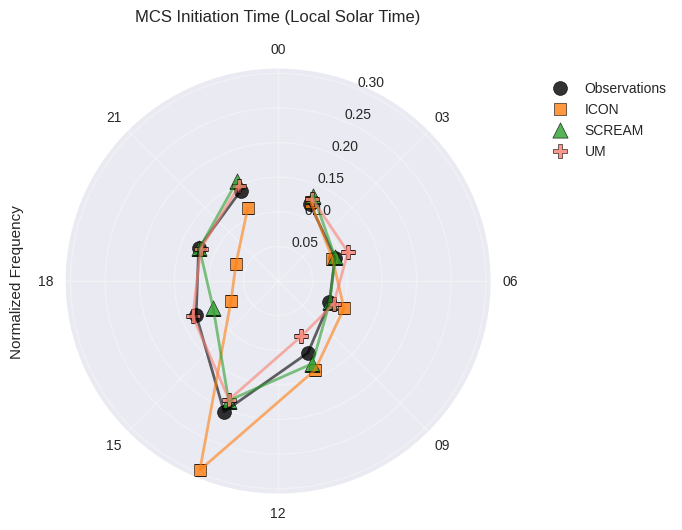

In [76]:
fig = plt.figure(figsize=(7, 7))
# ====== Polar scatter plot for Solar Time ======
ax9 = plt.subplot(1, 1, 1, projection='polar')

# Create polar histogram
theta_bins = np.linspace(0, 2*np.pi, 9)  # 8 bins for 3-hour intervals
theta_centers = (theta_bins[:-1] + theta_bins[1:]) / 2

# Define markers for each source
markers = {'Observations': 'o', 'ICON': 's', 'SCREAM': '^', 'UM': 'P'}
marker_sizes = {'Observations': 100, 'ICON': 80, 'SCREAM': 120, 'UM': 100}

for df, label in [(df_trop_obs, 'Observations'), (df_trop_icon, 'ICON'), (df_trop_scream, 'SCREAM'), (df_trop_um, 'UM')]:
    # Convert hours to radians (0 hours = top, clockwise)
    solar_radians = (df['local_solar_hour'] / 24) * 2 * np.pi
    
    # Create histogram
    counts, _ = np.histogram(solar_radians, bins=theta_bins)
    counts_normalized = counts / len(df)  # Normalize by total count
    
    # Plot as scatter points
    ax9.scatter(theta_centers, counts_normalized, 
               s=marker_sizes[label], alpha=0.8,
               label=label, color=colors[label], 
               marker=markers[label], 
               edgecolors='black', linewidth=0.5)

# Connect points with lines for better visualization
for df, label in [(df_trop_obs, 'Observations'), (df_trop_icon, 'ICON'), (df_trop_scream, 'SCREAM'), (df_trop_um, 'UM')]:
    solar_radians = (df['local_solar_hour'] / 24) * 2 * np.pi
    counts, _ = np.histogram(solar_radians, bins=theta_bins)
    counts_normalized = counts / len(df)
    
    # Add connecting lines
    ax9.plot(theta_centers, counts_normalized, 
             color=colors[label], alpha=0.6, linewidth=2)

# Set labels for 24-hour clock
ax9.set_xticks(np.linspace(0, 2*np.pi, 8, endpoint=False))
ax9.set_xticklabels(['00', '03', '06', '09', '12', '15', '18', '21'])
ax9.set_theta_zero_location('N')
ax9.set_theta_direction(-1)
ax9.set_title('MCS Initiation Time (Local Solar Time)', pad=15, fontsize=12)

# Customize the radial axis
ax9.set_ylim(0, None)
ax9.set_ylabel('Normalized Frequency', labelpad=30)

# Add legend with custom positioning
plt.legend(loc='upper left', bbox_to_anchor=(1.1, 1.0), fontsize=10)

# Add grid
ax9.grid(True, alpha=0.3)

plt.tight_layout()

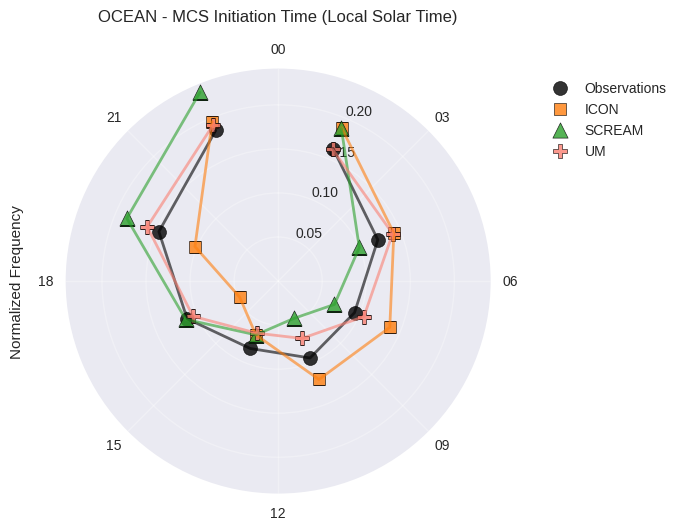

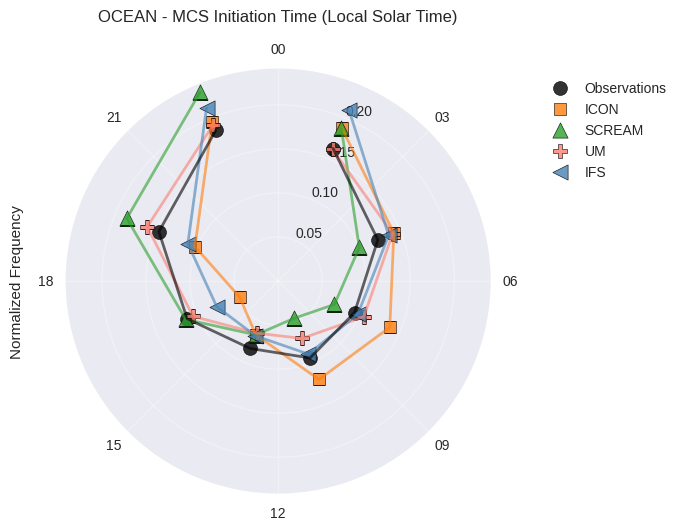

In [80]:
fig = plt.figure(figsize=(7, 7)) ###ONLY FREQUENCY
# ====== Polar scatter plot for Solar Time ======
ax9 = plt.subplot(1, 1, 1, projection='polar')

# Create polar histogram
theta_bins = np.linspace(0, 2*np.pi, 9)  # 8 bins for 3-hour intervals
theta_centers = (theta_bins[:-1] + theta_bins[1:]) / 2

# Define markers for each source
markers = {'Observations': 'o', 'ICON': 's', 'SCREAM': '^', 'UM': 'P','IFS': '<'}
marker_sizes = {'Observations': 100, 'ICON': 80, 'SCREAM': 120, 'UM': 100, 'IFS': 120}

for df, label in [(df_trop_obs[df_trop_obs[lf_var] <0.1],
                   'Observations'), 
                  (df_trop_icon[df_trop_icon[lf_var] <0.1], 'ICON'), 
                  (df_trop_scream[df_trop_scream[lf_var] <0.1], 'SCREAM'),
                 (df_trop_um[df_trop_um[lf_var] <0.1], 'UM'),(df_trop_ifs[df_trop_ifs[lf_var] <0.1], 'IFS')]:
    # Convert hours to radians (0 hours = top, clockwise)
    solar_radians = (df['local_solar_hour'] / 24) * 2 * np.pi
    
    # Create histogram
    counts, _ = np.histogram(solar_radians, bins=theta_bins)
    counts_normalized = counts / len(df)  # Normalize by total count
    
    # Plot as scatter points
    ax9.scatter(theta_centers, counts_normalized, 
               s=marker_sizes[label], alpha=0.8,
               label=label, color=colors[label], 
               marker=markers[label], 
               edgecolors='black', linewidth=0.5)

# Connect points with lines for better visualization
for df, label in [
                  (df_trop_icon[df_trop_icon[lf_var] <0.1], 'ICON'), 
                  (df_trop_scream[df_trop_scream[lf_var] <0.1], 'SCREAM'),
                 (df_trop_um[df_trop_um[lf_var] <0.1], 'UM'),
                 (df_trop_ifs[df_trop_ifs[lf_var] <0.1], 'IFS'),
(df_trop_obs[df_trop_obs[lf_var] <0.1], 'Observations'), ]:
    solar_radians = (df['local_solar_hour'] / 24) * 2 * np.pi
    counts, _ = np.histogram(solar_radians, bins=theta_bins)
    counts_normalized = counts / len(df)
    
    # Add connecting lines
    ax9.plot(theta_centers, counts_normalized, 
             color=colors[label], alpha=0.6, linewidth=2)

# Set labels for 24-hour clock
ax9.set_xticks(np.linspace(0, 2*np.pi, 8, endpoint=False))
ax9.set_xticklabels(['00', '03', '06', '09', '12', '15', '18', '21'])
ax9.set_theta_zero_location('N')
ax9.set_theta_direction(-1)
ax9.set_title('OCEAN - MCS Initiation Time (Local Solar Time)', pad=15, fontsize=12)

# Customize the radial axis
ax9.set_ylim(0, None)
ax9.set_ylabel('Normalized Frequency', labelpad=30)

# Add legend with custom positioning
plt.legend(loc='upper left', bbox_to_anchor=(1.1, 1.0), fontsize=10)

# Add grid
ax9.grid(True, alpha=0.3)

plt.tight_layout()

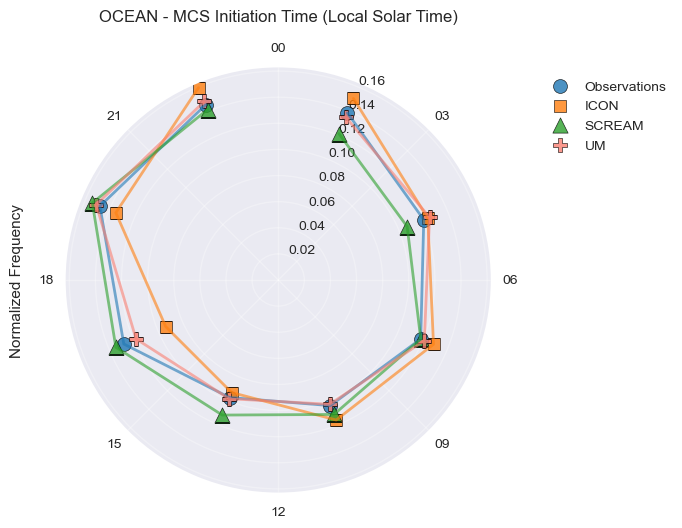

In [18]:
#old

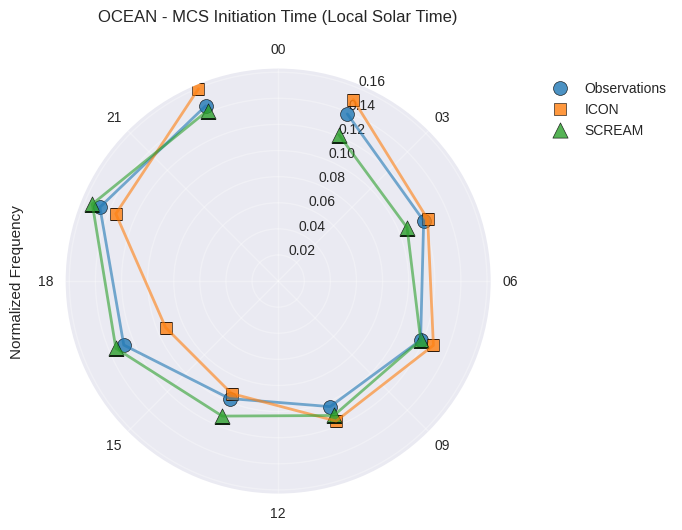

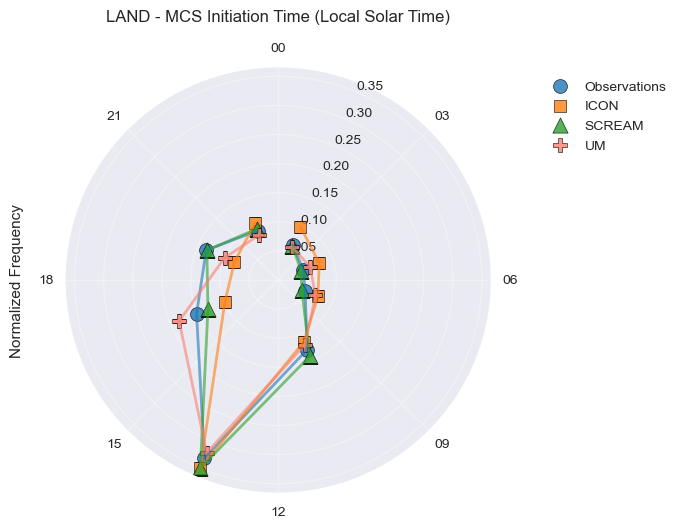

In [19]:
fig = plt.figure(figsize=(7, 7))
# ====== Polar scatter plot for Solar Time ======
ax9 = plt.subplot(1, 1, 1, projection='polar')

# Create polar histogram
theta_bins = np.linspace(0, 2*np.pi, 9)  # 8 bins for 3-hour intervals
theta_centers = (theta_bins[:-1] + theta_bins[1:]) / 2

# Define markers for each source
markers = {'Observations': 'o', 'ICON': 's', 'SCREAM': '^', 'UM': 'P'}
marker_sizes = {'Observations': 100, 'ICON': 80, 'SCREAM': 120, 'UM': 100}

for df, label in [(df_trop_obs[df_trop_obs[lf_var] >0.9],
                   'Observations'), 
                  (df_trop_icon[df_trop_icon[lf_var] >0.9], 'ICON'), 
                  (df_trop_scream[df_trop_scream[lf_var] >0.9], 'SCREAM'),
                 (df_trop_um[df_trop_um[lf_var] >0.9], 'UM')]:
    # Convert hours to radians (0 hours = top, clockwise)
    solar_radians = (df['local_solar_hour'] / 24) * 2 * np.pi
    
    # Create histogram
    counts, _ = np.histogram(solar_radians, bins=theta_bins)
    counts_normalized = counts / len(df)  # Normalize by total count
    
    # Plot as scatter points
    ax9.scatter(theta_centers, counts_normalized, 
               s=marker_sizes[label], alpha=0.8,
               label=label, color=colors[label], 
               marker=markers[label], 
               edgecolors='black', linewidth=0.5)

# Connect points with lines for better visualization
for df, label in [(df_trop_obs[df_trop_obs[lf_var] >0.9], 'Observations'), 
                  (df_trop_icon[df_trop_icon[lf_var] >0.9], 'ICON'), 
                  (df_trop_scream[df_trop_scream[lf_var] >0.9], 'SCREAM'),
                 (df_trop_um[df_trop_um[lf_var] >0.9], 'UM')]:
    solar_radians = (df['local_solar_hour'] / 24) * 2 * np.pi
    counts, _ = np.histogram(solar_radians, bins=theta_bins)
    counts_normalized = counts / len(df)
    
    # Add connecting lines
    ax9.plot(theta_centers, counts_normalized, 
             color=colors[label], alpha=0.6, linewidth=2)

# Set labels for 24-hour clock
ax9.set_xticks(np.linspace(0, 2*np.pi, 8, endpoint=False))
ax9.set_xticklabels(['00', '03', '06', '09', '12', '15', '18', '21'])
ax9.set_theta_zero_location('N')
ax9.set_theta_direction(-1)
ax9.set_title('LAND - MCS Initiation Time (Local Solar Time)', pad=15, fontsize=12)

# Customize the radial axis
ax9.set_ylim(0, None)
ax9.set_ylabel('Normalized Frequency', labelpad=30)

# Add legend with custom positioning
plt.legend(loc='upper left', bbox_to_anchor=(1.1, 1.0), fontsize=10)

# Add grid
ax9.grid(True, alpha=0.3)

plt.tight_layout()


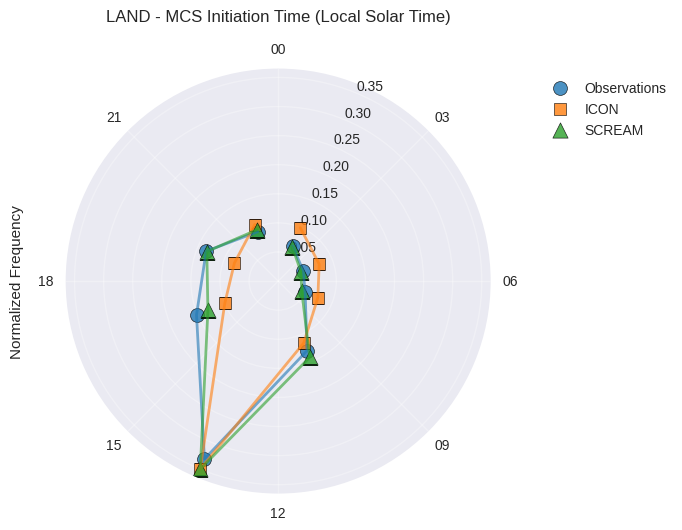

In [47]:
df_trop_obs.columns

Index(['track_id', 'duration_hours', 'initial_lat', 'initial_lon', 'mean_area',
       'median_area', 'total_area', 'start_time', 'local_solar_hour',
       'source'],
      dtype='object')

In [51]:
df_trop_obs['duration_hours'].quantile(.5)

np.float64(17.0)

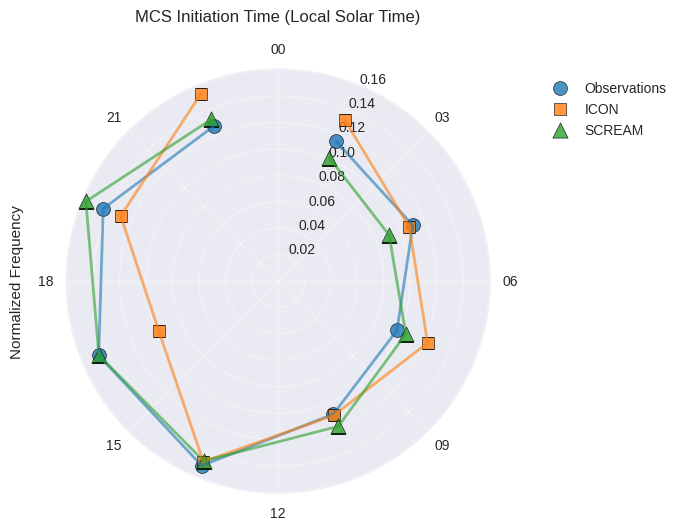

In [55]:
fig = plt.figure(figsize=(7, 7)); pc = 0.9
# ====== Polar scatter plot for Solar Time ======
ax9 = plt.subplot(1, 1, 1, projection='polar')

# Create polar histogram
theta_bins = np.linspace(0, 2*np.pi, 9)  # 8 bins for 3-hour intervals
theta_centers = (theta_bins[:-1] + theta_bins[1:]) / 2

# Define markers for each source
markers = {'Observations': 'o', 'ICON': 's', 'SCREAM': '^'}
marker_sizes = {'Observations': 100, 'ICON': 80, 'SCREAM': 120}

for df, label in [(df_trop_obs[df_trop_obs.duration_hours>df_trop_obs['duration_hours'].quantile(pc)],
                   'Observations'), 
                  (df_trop_icon[df_trop_icon.duration_hours>df_trop_icon['duration_hours'].quantile(pc)], 'ICON'), 
                  (df_trop_scream[df_trop_scream.duration_hours>df_trop_scream['duration_hours'].quantile(pc)], 'SCREAM')]:
    # Convert hours to radians (0 hours = top, clockwise)
    solar_radians = (df['local_solar_hour'] / 24) * 2 * np.pi
    
    # Create histogram
    counts, _ = np.histogram(solar_radians, bins=theta_bins)
    counts_normalized = counts / len(df)  # Normalize by total count
    
    # Plot as scatter points
    ax9.scatter(theta_centers, counts_normalized, 
               s=marker_sizes[label], alpha=0.8,
               label=label, color=colors[label], 
               marker=markers[label], 
               edgecolors='black', linewidth=0.5)

# Connect points with lines for better visualization
for df, label in [(df_trop_obs[df_trop_obs.duration_hours>df_trop_obs['duration_hours'].quantile(pc)], 
                   'Observations'), 
                  (df_trop_icon[df_trop_icon.duration_hours>df_trop_icon['duration_hours'].quantile(pc)], 'ICON'), 
                  (df_trop_scream[df_trop_scream.duration_hours>df_trop_scream['duration_hours'].quantile(pc)],
                   'SCREAM')]:
    solar_radians = (df['local_solar_hour'] / 24) * 2 * np.pi
    counts, _ = np.histogram(solar_radians, bins=theta_bins)
    counts_normalized = counts / len(df)
    
    # Add connecting lines
    ax9.plot(theta_centers, counts_normalized, 
             color=colors[label], alpha=0.6, linewidth=2)

# Set labels for 24-hour clock
ax9.set_xticks(np.linspace(0, 2*np.pi, 8, endpoint=False))
ax9.set_xticklabels(['00', '03', '06', '09', '12', '15', '18', '21'])
ax9.set_theta_zero_location('N')
ax9.set_theta_direction(-1)
ax9.set_title('MCS Initiation Time (Local Solar Time)', pad=15, fontsize=12)

# Customize the radial axis
ax9.set_ylim(0, None)
ax9.set_ylabel('Normalized Frequency', labelpad=30)

# Add legend with custom positioning
plt.legend(loc='upper left', bbox_to_anchor=(1.1, 1.0), fontsize=10)

# Add grid
ax9.grid(True, alpha=0.3)

plt.tight_layout()